In [8]:
!pip install librosa gradio

Defaulting to user installation because normal site-packages is not writeable
  Using cached librosa-1.0.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached soundfile-0.14.0-py2.py3-none-win_amd64.whl.metadata (18 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached soxr-1.1.0-cp312-abi3-win_amd64.whl.metadata (5.8 kB)
Using cached librosa-1.0.0-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Total audio files: 2000
            filename        category
0   1-100032-A-0.wav             dog
1  1-100038-A-14.wav  chirping_birds
2  1-100210-A-36.wav  vacuum_cleaner
3  1-100210-B-36.wav  vacuum_cleaner
4  1-101296-A-19.wav    thunderstorm


C:\Users\WALEED TRADERS\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


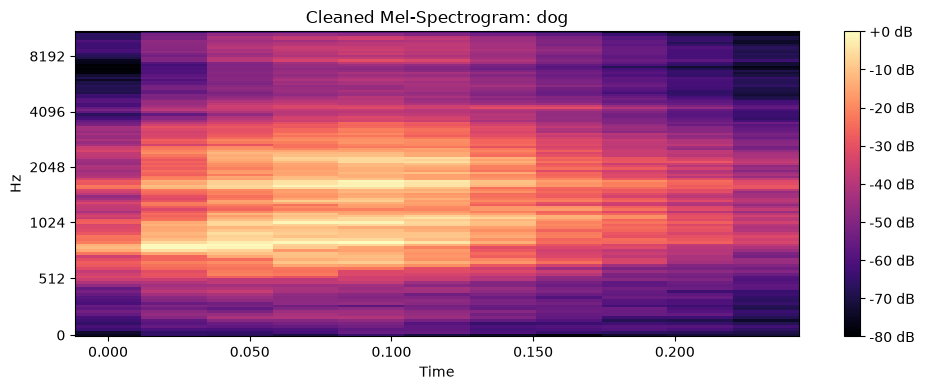

In [3]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# 1. Dataset Directory Setup
DATASET_PATH = "./"  # Path of Folder
CSV_PATH = os.path.join(DATASET_PATH, "esc50.csv")
AUDIO_DIR = os.path.join(DATASET_PATH, "audio/audio/44100") if os.path.exists(os.path.join(DATASET_PATH, "audio/audio/44100")) else os.path.join(DATASET_PATH, "audio")

# 2. Load the Metadata
df = pd.read_csv(CSV_PATH)
print("Total audio files:", len(df))
print(df[['filename', 'category']].head())

# 3. Audio Cleaning & Feature Extraction Function
def preprocess_audio(file_path, target_sr=22050):
    # Resample audio to standard rate
    audio, sr = librosa.load(file_path, sr=target_sr, mono=True)
    
    # Silence Trimming (reduce the useless gap from start and from the end)
    audio_trimmed, _ = librosa.effects.trim(audio, top_db=20)
    
    # Extract the Mel-Spectrogram (to make the audio into 2D image)
    mel_spec = librosa.feature.melspectrogram(y=audio_trimmed, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    return audio_trimmed, sr, mel_spec_db

# 4. First Audio Clean & Visualize Test
sample_file = df.iloc[0]['filename']
sample_category = df.iloc[0]['category']
sample_path = os.path.join(AUDIO_DIR, sample_file)

audio_data, sr, spectrogram = preprocess_audio(sample_path)

# Plot Spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(spectrogram, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title(f'Cleaned Mel-Spectrogram: {sample_category}')
plt.tight_layout()
plt.show()

In [4]:
import os
import pandas as pd
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm

# Paths setup
DATASET_PATH = "./"
CSV_PATH = os.path.join(DATASET_PATH, "esc50.csv")
AUDIO_DIR = os.path.join(DATASET_PATH, "audio/audio/44100") if os.path.exists(os.path.join(DATASET_PATH, "audio/audio/44100")) else os.path.join(DATASET_PATH, "audio")

df = pd.read_csv(CSV_PATH)

# Arrays setup
X = []
y = []

# Fixed shape setup (Spectrogram consistency)
MAX_PAD_LEN = 174  # Standard time frames length

print("Bulk feature extraction processing starting...")

for idx, row in tqdm(df.iterrows(), total=len(df)):
    file_path = os.path.join(AUDIO_DIR, row['filename'])
    label = row['category']
    
    try:
        # Audio Load & Resample (22.05 kHz)
        audio, sr = librosa.load(file_path, sr=22050, mono=True)
        
        # Silence Trimming
        audio_trimmed, _ = librosa.effects.trim(audio, top_db=20)
        
        # Mel-Spectrogram Extraction
        mel_spec = librosa.feature.melspectrogram(y=audio_trimmed, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Shape Padding / Truncating
        if mel_spec_db.shape[1] < MAX_PAD_LEN:
            pad_width = MAX_PAD_LEN - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :MAX_PAD_LEN]
            
        X.append(mel_spec_db)
        y.append(label)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")

# Convert lists to Numpy arrays
X = np.array(X)
y = np.array(y)

print("\nFeature extraction complete!")
print("X shape (Total Samples, Height, Width):", X.shape)
print("y shape:", y.shape)

Bulk feature extraction processing starting...


100%|██████████| 2000/2000 [02:18<00:00, 14.45it/s]



Feature extraction complete!
X shape (Total Samples, Height, Width): (2000, 128, 174)
y shape: (2000,)


In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
# 1. Label Encoding (Text categories to numbers 0-49)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 2. Reshape X for 2D CNN (Height, Width, Channel=1)
X_reshaped = X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

# 3. Train / Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Data Splitting Successful!")
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

# 4. Save arrays to disk
np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)
np.save("classes.npy", le.classes_)

print("All preprocessed numpy files successfully saved to disk!")

Data Splitting Successful!
Training Data Shape: (1600, 128, 174, 1)
Testing Data Shape: (400, 128, 174, 1)
All preprocessed numpy files successfully saved to disk!


In [4]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 419.6 kB/s eta 0:00:22
   --- ------------------------------------ 0.8/9.5 MB 695.3 kB/s eta 0:00:13
   ---- ----------------------------------- 1.0/9.5 MB 755.3 kB/s eta 0:00:12
   ---- ----------------------------------- 1.0/9.5 MB 755.3 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.5 MB 699.0 kB/s eta 0:00:12
   ------ --------------------------------- 1.6/9.5 MB 724.0 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/9.5 MB 724.0 kB/s eta 0:00:11
   ------- -------------------------------- 1.8/9.5 MB 740.9 kB/s eta 0:00:11
   ------- -----------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Saved preprocessed numpy files load karna
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")
classes = np.load("classes.npy")

print("Data successfully loaded from disk!")
print("Input shape for CNN:", X_train.shape[1:])
print("Total output classes:", len(classes))

# 2. 2D CNN Model Architecture Design
model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Third Convolutional Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.BatchNormalization(),
    
    # Fully Connected Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),  # Overfitting ko rokne ke liye
    layers.Dense(len(classes), activation='softmax')  # 50 sound categories output
])

# 3. Model Compilation
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary display karna
model.summary()

# 4. Model Training Start Karna (30 Epochs)
print("\nStarting Model Training...")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# 5. Trained Model Ko Save Karna
model.save("audio_classification_cnn.h5")
print("\nModel successfully trained and saved as 'audio_classification_cnn.h5'!")

Matplotlib is building the font cache; this may take a moment.


Data successfully loaded from disk!
Input shape for CNN: (128, 174, 1)
Total output classes: 50


C:\Users\WALEED TRADERS\AppData\Roaming\Python\Python314\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 172, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 86, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 42, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 35840)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,175,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281,714 (35.41 MB)

 Trainable params: 9,281,266 (35.41 MB)

 Non-trainable params: 448 (1.75 KB)


Starting Model Training...
Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.1150 - loss: 8.5717 - val_accuracy: 0.0250 - val_loss: 21.5127
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.1844 - loss: 4.2258 - val_accuracy: 0.0600 - val_loss: 5.5523
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.2481 - loss: 3.4843 - val_accuracy: 0.1225 - val_loss: 3.9819
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.3156 - loss: 2.8912 - val_accuracy: 0.1975 - val_loss: 3.6577
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.3794 - loss: 2.6823 - val_accuracy: 0.1775 - val_loss: 3.5397
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 2s/step - accuracy: 0.3837 - loss: 2.6518 - val_accuracy: 0.1125 - val_loss: 4.3586
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 63s 1s/step - accuracy: 0.4531 - loss: 2.1386 - val_accuracy: 0.1650 - val_loss: 6.7933
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.5125 - loss: 1.7630 -


Model successfully trained and saved as 'audio_classification_cnn.h5'!


In [6]:
!pip install gradio

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/31.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/31.4 MB ? eta -:--:--
   ---------


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
!pip install soundfile librosa


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import numpy as np
import tensorflow as tf
import librosa
import gradio as gr

# 1. Load Model and Saved Class Names
model = tf.keras.models.load_model("audio_classification_cnn.h5")
classes = np.load("classes.npy")

def predict_audio(audio_path):
    if audio_path is None:
        return "Please upload an audio file."
    
    # 2. Load Audio Signal (22050 Hz, Mono)
    y, sr = librosa.load(audio_path, sr=22050, mono=True)
    
    # 3. Trim Silence
    y, _ = librosa.effects.trim(y, top_db=20)
    
    # 4. Extract Mel-Spectrogram (128 Bins)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # 5. FIX SHAPE: Enforce Exact Model Width (174)
    target_width = 174
    current_width = mel_spec_db.shape[1]
    
    if current_width < target_width:
        mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, target_width - current_width)), mode='constant')
    else:
        mel_spec_db = mel_spec_db[:, :target_width]
        
    # 6. Reshape for CNN Model Input: (1, 128, 174, 1)
    mel_spec_input = mel_spec_db[..., np.newaxis]
    mel_spec_input = np.expand_dims(mel_spec_input, axis=0)
    
    # 7. Model Prediction
    predictions = model.predict(mel_spec_input, verbose=0)[0]
    
    # 8. Return Top 5 Categories
    top_indices = np.argsort(predictions)[::-1][:5]
    return {str(classes[i]): float(predictions[i]) for i in top_indices}

# 9. Interface Launch
interface = gr.Interface(
    fn=predict_audio,
    inputs=gr.Audio(type="filepath", label="Upload Audio File"),
    outputs=gr.Label(num_top_classes=5, label="Top 5 Predictions"),
    title="🎵 ESC-50 Environmental Sound Classifier"
)

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7868
* Running on public URL: https://bcd9002d364f019e34.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [20]:
!pip install seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Test set par predictions generate karna
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# 2. Automatically handle 1D integer labels vs 2D One-Hot labels
if y_test.ndim > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test

# 3. Detailed Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=classes))

# 4. Confusion Matrix Plot
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix - Baseline 2D CNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 275ms/step
=== CLASSIFICATION REPORT ===


C:\Users\WALEED TRADERS\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\WALEED TRADERS\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\WALEED TRADERS\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

                  precision    recall  f1-score   support

        airplane       0.00      0.00      0.00         8
       breathing       0.00      0.00      0.00         8
  brushing_teeth       0.50      0.12      0.20         8
     can_opening       0.14      0.12      0.13         8
        car_horn       0.27      0.38      0.32         8
             cat       0.38      0.38      0.38         8
        chainsaw       0.29      0.62      0.40         8
  chirping_birds       0.00      0.00      0.00         8
    church_bells       1.00      0.50      0.67         8
        clapping       0.50      0.62      0.56         8
     clock_alarm       1.00      0.88      0.93         8
      clock_tick       1.00      0.12      0.22         8
        coughing       0.30      0.75      0.43         8
             cow       0.50      0.25      0.33         8
  crackling_fire       0.00      0.00      0.00         8
        crickets       0.08      0.50      0.14         8
            c

<Figure size 1200x1000 with 2 Axes>

In [23]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# 1. Spectrogram features ko 2D Flatten karna (Samples, Features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Flattened Train Shape: {X_train_flat.shape}")
print(f"Flattened Test Shape: {X_test_flat.shape}\n")

# 2. Random Forest Classifier
print("--- Training Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_true_train if 'y_true_train' in locals() else np.argmax(y_train, axis=1) if y_train.ndim > 1 else y_train)
rf_preds = rf.predict(X_test_flat)
rf_acc = accuracy_score(y_true, rf_preds)
print(f"Random Forest Test Accuracy: {rf_acc * 100:.2f}%\n")

# 3. Support Vector Machine (SVM)
print("--- Training SVM Classifier ---")
svm = SVC(kernel='rbf', C=1.0)
svm.fit(X_train_flat, y_true_train if 'y_true_train' in locals() else np.argmax(y_train, axis=1) if y_train.ndim > 1 else y_train)
svm_preds = svm.predict(X_test_flat)
svm_acc = accuracy_score(y_true, svm_preds)
print(f"SVM Test Accuracy: {svm_acc * 100:.2f}%\n")

Flattened Train Shape: (1600, 22272)
Flattened Test Shape: (400, 22272)

--- Training Random Forest ---
Random Forest Test Accuracy: 38.00%

--- Training SVM Classifier ---
SVM Test Accuracy: 31.50%



In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization
import librosa

# 1. Data Augmentation Function on Audio Array
def augment_audio(y, sr):
    choice = np.random.choice(['noise', 'pitch', 'speed', 'none'])
    if choice == 'noise':
        noise = np.random.randn(len(y)) * 0.005
        return y + noise
    elif choice == 'pitch':
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.randint(-2, 3))
    elif choice == 'speed':
        return librosa.effects.time_stretch(y, rate=np.random.uniform(0.8, 1.2))
    return y

print("Data Augmentation setup ready!")

# 2. Advanced Regularized 2D CNN Architecture
model_augmented = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 174, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    
    # Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),
    
    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),
    
    # Dense Classifier
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model_augmented.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy' if y_train.ndim > 1 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_augmented.summary()

Data Augmentation setup ready!


C:\Users\WALEED TRADERS\AppData\Roaming\Python\Python314\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 172, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 172, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 63, 86, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 84, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 84, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 42, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 35840)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,175,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │        12,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,282,738 (35.41 MB)

 Trainable params: 9,281,778 (35.41 MB)

 Non-trainable params: 960 (3.75 KB)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks for optimal training
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# Training execution
print("=== Starting Improved CNN Training ===")
history_augmented = model_augmented.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Improved Model Save
model_augmented.save("audio_classification_cnn_improved.h5")
print("\nImproved Model saved as 'audio_classification_cnn_improved.h5'")

=== Starting Improved CNN Training ===
Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 166s 3s/step - accuracy: 0.1075 - loss: 4.0118 - val_accuracy: 0.0375 - val_loss: 4.8560 - learning_rate: 5.0000e-04
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 173s 3s/step - accuracy: 0.2581 - loss: 2.8951 - val_accuracy: 0.0725 - val_loss: 4.1626 - learning_rate: 5.0000e-04
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.3738 - loss: 2.3465 - val_accuracy: 0.0975 - val_loss: 4.3039 - learning_rate: 5.0000e-04
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.4988 - loss: 1.8065 - val_accuracy: 0.1150 - val_loss: 4.3836 - learning_rate: 5.0000e-04
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.6219 - loss: 1.3614 - val_accuracy: 0.1550 - val_loss: 4.1184 - learning_rate: 5.0000e-04
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.7269 - loss: 1.0451 - val_accuracy: 0.1950 - val_loss: 4.5161 - learning_rate: 5.0000e-04
Epoch 7/40
50/50 ━━━━━━━━━━━━━━


Improved Model saved as 'audio_classification_cnn_improved.h5'


In [26]:
import matplotlib.pyplot as plt

# Plot Accuracy & Loss comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax[0].plot(history_augmented.history['accuracy'], label='Train Accuracy', color='blue')
ax[0].plot(history_augmented.history['val_accuracy'], label='Val Accuracy', color='orange')
ax[0].set_title('Improved CNN - Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

# Loss Plot
ax[1].plot(history_augmented.history['loss'], label='Train Loss', color='blue')
ax[1].plot(history_augmented.history['val_loss'], label='Val Loss', color='orange')
ax[1].set_title('Improved CNN - Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

<Figure size 1400x500 with 2 Axes>

In [27]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Reshape 1-channel Spectrograms to 3-channel RGB for Pre-trained Models
print("Converting 1-channel spectrograms to 3-channel RGB...")
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

print(f"New Train Shape: {X_train_rgb.shape}")
print(f"New Test Shape: {X_test_rgb.shape}")

# 2. Base Model Initialization (MobileNetV2 with ImageNet Weights)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 174, 3)
)
base_model.trainable = False  # Freeze pre-trained layers initially

# 3. Transfer Learning Architecture
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(len(classes), activation='softmax')
])

# 4. Compile Model
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy' if y_train.ndim > 1 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Callbacks
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# 6. Train Model
print("\n=== Training Transfer Learning (MobileNetV2) ===")
history_tl = model_tl.fit(
    X_train_rgb, y_train,
    validation_data=(X_test_rgb, y_test),
    epochs=25,
    batch_size=32,
    callbacks=callbacks_tl,
    verbose=1
)

# Save Transfer Learning Model
model_tl.save("audio_classification_mobilenetv2.h5")
print("\nTransfer Learning Model saved successfully!")

Converting 1-channel spectrograms to 3-channel RGB...
New Train Shape: (1600, 128, 174, 3)
New Test Shape: (400, 128, 174, 3)


C:\Users\WALEED TRADERS\AppData\Local\Temp\ipykernel_41332\3908577368.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 13s 1us/step

=== Training Transfer Learning (MobileNetV2) ===
Epoch 1/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 37s 618ms/step - accuracy: 0.1144 - loss: 3.6262 - val_accuracy: 0.2900 - val_loss: 2.8859 - learning_rate: 0.0010
Epoch 2/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 542ms/step - accuracy: 0.2781 - loss: 2.7195 - val_accuracy: 0.3900 - val_loss: 2.3665 - learning_rate: 0.0010
Epoch 3/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 540ms/step - accuracy: 0.3656 - loss: 2.2866 - val_accuracy: 0.4500 - val_loss: 2.0736 - learning_rate: 0.0010
Epoch 4/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 540ms/step - accuracy: 0.4494 - loss: 1.9765 - val_accuracy: 0.4625 - val_loss: 1.9100 - learning_rate: 0.0010
Epoch 5/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 548ms/step - accuracy: 0.4981 - loss: 1.7729 - val_accuracy: 0.4900 - val_loss: 1.7830 - learning_rate: 0.0010
Epoch 6/25
50/50 ━━━━━━━━━━━━━━━━━━━━ 41s 537ms/step - accuracy: 0.5281 - loss: 1.6086 - val_accuracy: 0.5050 - val_loss: 1.7411 - lear


Transfer Learning Model saved successfully!


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Classes array define / load karna
if 'le' in locals():
    classes = le.classes_
else:
    classes = np.load("classes.npy", allow_pickle=True)

# 2. Spectrograms ko 3-channel RGB format mein convert karna
X_train_rgb = np.repeat(X_train, 3, axis=-1)
X_test_rgb = np.repeat(X_test, 3, axis=-1)

# 3. Base Model Initialize karna
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 174, 3)
)

# 4. Early layers ko freeze karke top layers ko unfreeze karna
base_model.trainable = True
fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 5. Transfer Learning Architecture assemble karna
model_tl = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(len(classes), activation='softmax')
])

# 6. Low Learning Rate se Compile karna
model_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy' if y_train.ndim > 1 else 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Callbacks setup karna
callbacks_tl = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# 8. Fine-Tuning Training execute karna
print("=== Starting Fine-Tuning Phase ===")
history_finetune = model_tl.fit(
    X_train_rgb, y_train,
    validation_data=(X_test_rgb, y_test),
    epochs=15,
    batch_size=32,
    callbacks=callbacks_tl,
    verbose=1
)

# Final Fine-Tuned Model Save karna
model_tl.save("audio_classification_mobilenetv2_finetuned.h5")
print("\nFine-tuned Transfer Learning Model Saved Successfully!")

C:\Users\WALEED TRADERS\AppData\Local\Temp\ipykernel_5608\1891752284.py:19: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


=== Starting Fine-Tuning Phase ===
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.0225 - loss: 4.2818 - val_accuracy: 0.0100 - val_loss: 4.2496 - learning_rate: 1.0000e-05
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.0494 - loss: 3.9485 - val_accuracy: 0.0100 - val_loss: 4.1792 - learning_rate: 1.0000e-05
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.0700 - loss: 3.7299 - val_accuracy: 0.0125 - val_loss: 4.1111 - learning_rate: 1.0000e-05
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.1037 - loss: 3.5274 - val_accuracy: 0.0150 - val_loss: 4.0471 - learning_rate: 1.0000e-05
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.1494 - loss: 3.3565 - val_accuracy: 0.0300 - val_loss: 3.9872 - learning_rate: 1.0000e-05
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.2206 - loss: 3.1480 - val_accuracy: 0.0375 - val_loss: 3.9313 - learning_rate: 1.0000e-05
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8


Fine-tuned Transfer Learning Model Saved Successfully!
